# Module 2 · Transformers — Lab 3: Fine-tuning knobs
## Where the classifier reads, how deep it trains, and where its accuracy comes from

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mago-cinv/course-template/blob/master/modules/02-transformers/labs/homework/lab-3-variants-assignament.ipynb)

This homework pairs with **Lesson 3** ("Architecture variations"), and uses two of its families —
`distilbert-base-uncased` (encoder-only) and `gpt2` (decoder-only) — on one application: **binary
sentiment classification on SST-2**.

### The question behind the whole lab

Fine-tuning a pretrained transformer for classification looks like three lines of Hugging Face. Those
three lines quietly decide several things for you. `AutoModelForSequenceClassification` **hardcodes
which hidden state the classifier head reads** — BERT's pooler takes `[CLS]`, GPT-2 takes the last
non-pad token — and the usual recipe fine-tunes *every* weight in the body without ever asking how
many of them actually needed to move.

Nobody asked whether those are the right choices. To ask, each one has to become a **knob** you can
turn and measure, which means writing our own classifier head. That is what the knob bench in Part 0
is for.

### How this homework works

**The machinery is given to you and has already run.** Part 0 loads a small SST-2 slice and builds
the bench: a classifier whose readout position is configurable, a fine-tune function that **hands the
trained model back to you**, and a grid runner that sweeps configurations into a table and a plot.
None of it needs you to look up a library signature — it is all written, commented, and demonstrated
below.

**What you write is the investigation.** Four experiments (🔬 **A1**–**A4**) point that bench at four
questions: *where* should the head read from, *how much* of the body has to move, *where* the accuracy
actually comes from, and *what* the trained model really does on sentences you wrote yourself. The
experiments must *run*, because every conclusion has to cite numbers **you** printed.

**Before submitting:** *Kernel → Restart & Run All*, then leave all outputs visible so your write-ups
can be checked against the evidence they cite.

*Knob set adapted from the ablation table in [`rasbt/LLMs-from-scratch`](https://github.com/rasbt/LLMs-from-scratch/tree/main/ch06/02_bonus_additional-experiments)
(`ch06/02_bonus_additional-experiments`, Apache-2.0) — the questions are borrowed, the code here is
written fresh against this notebook's own sandbox.*

*Model downloads ≈ 0.5 GB (two checkpoints), cached after the first run. On Colab use **Runtime ▸
Change runtime type ▸ GPU** if you have it. Fine-tuned weights are **hardware-dependent** — same seed
on a different machine gives visibly different numbers; that is expected, and nothing here is graded
against a reference figure.*

**Entregado por:** Emmanuel Modesto Orozco 


In [1]:
# Setup — run me first (works on Colab AND locally)
import sys

if "google.colab" in sys.modules:
    %pip install -q transformers datasets evaluate accelerate

print("Setup OK —", "Colab" if "google.colab" in sys.modules else "local Python", sys.version.split()[0])

Setup OK — local Python 3.12.13


In [2]:
# Imports, seeds, device — run me second
import gc, math, os, re, time, warnings

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import transformers
from datasets import load_dataset
from transformers import (AutoConfig, AutoModel, AutoTokenizer,
                           DataCollatorWithPadding, Trainer, TrainingArguments, set_seed)

transformers.logging.set_verbosity_error()   # quiet down "newly initialized weights" chatter

SEED = 0
set_seed(SEED); torch.manual_seed(SEED); np.random.seed(SEED)

DEVICE = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"device: {DEVICE}")
if DEVICE == "cpu":
    print("  ⏳ running on CPU.")
    print("     On Colab, Runtime ▸ Change runtime type ▸ GPU will be faster if available.")
else:
    print("  ✓ accelerator found.")
print("⚠ ~0.5 GB of model downloads on first run (distilbert-base-uncased + gpt2), cached after.")
print("⚠ Fine-tuned weights are HARDWARE-dependent: same seed, different machine → visibly different")
print("   numbers. Nothing here is graded against a reference figure.")

device: cuda
  ✓ accelerator found.
⚠ ~0.5 GB of model downloads on first run (distilbert-base-uncased + gpt2), cached after.
⚠ Fine-tuned weights are HARDWARE-dependent: same seed, different machine → visibly different
   numbers. Nothing here is graded against a reference figure.


## Part 0 — The sandbox (provided, already run)

Everything in Part 0 is **given to you and already works**: the SST-2 slice, two small helpers, and
the knob bench itself (a configurable-readout classifier, a fine-tune-and-keep function, a grid
runner). Read it once, run it, then go use it in A1–A4.

### 0.1 · The task and the data — SST-2

The application is **binary sentiment classification**: given one short movie-review sentence, answer
*positive* or *negative*. **SST-2** (Stanford Sentiment Treebank) is its standard benchmark.

A deterministic slice: the first **300** training sentences to fine-tune on, the first **100** of the
*validation* split as held-out evaluation (SST-2's test labels are hidden). Small on purpose — every
exercise below fine-tunes several models, so each single run has to be cheap.

In [3]:
ds = load_dataset("nyu-mll/glue", "sst2")     # ⚠ gotcha #3: the bare "glue" alias errors on datasets >= 5
train_small = ds["train"].select(range(300))
eval_small = ds["validation"].select(range(100))

names = {0: "negative", 1: "positive"}
print(f"train {len(train_small)}   eval {len(eval_small)}")
print(f"eval class balance: {np.bincount(eval_small['label']).tolist()}  (chance ≈ 0.5)")
print()
for i in (0, 1):
    print(f"  [{names[eval_small[i]['label']]}] {eval_small[i]['sentence'].strip()}")

README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

train 300   eval 100
eval class balance: [48, 52]  (chance ≈ 0.5)

  [positive] it 's a charming and often affecting journey .
  [negative] unflinchingly bleak and desperate


### 0.2 · Two small helpers the bench uses

The accuracy metric, the quiet `TrainingArguments` every run shares, and the label words used when a
model's predictions are printed back as text.

In [4]:
LABEL_WORDS = {0: "negative", 1: "positive"}


def _accuracy_metric(eval_pred):
    preds = np.argmax(eval_pred.predictions, axis=-1)
    return {"accuracy": float((preds == eval_pred.label_ids).mean())}


def _quiet_args(out_dir, epochs, batch_size, seed):
    return TrainingArguments(output_dir=out_dir, num_train_epochs=epochs,
                              per_device_train_batch_size=batch_size,
                              per_device_eval_batch_size=batch_size,
                              logging_steps=1000, report_to=[], seed=seed,
                              disable_tqdm=True, eval_strategy="no", save_strategy="no")


print("helpers ready: LABEL_WORDS / _accuracy_metric / _quiet_args")

helpers ready: LABEL_WORDS / _accuracy_metric / _quiet_args


### 0.3 · The knob bench (provided, already run)

One function, `finetune_with_knobs(**knobs)`, fine-tunes a body and **hands the model back**. Every
knob has a default, so `finetune_with_knobs()` with no arguments is a complete run.

| knob | values | default | what it actually changes |
|---|---|---|---|
| `model_name` | `"distilbert-base-uncased"` · `"gpt2"` | `"distilbert-base-uncased"` | which family — and depth (6 vs 12 blocks) |
| `readout` | `"first"` · `"last"` · `"mean"` | `"mean"` | which hidden state the head reads. `first` is `[CLS]` in BERT, token 0 in GPT-2 |
| `trainable` | `"head"` · `"last1"` · `"last2"` · `"all"` | `"all"` | how much of the body gets gradients (the head always trains) |
| `pretrained` | `True` · `False` | `True` | pretrained weights, or the **identical architecture** with random ones |
| `n_train` | 1 – 300 | `300` | sentences taken from `train_small`. **This is the cost lever** |
| `epochs` · `batch_size` · `max_length` | — | `3` · `8` · `32` | the budget |
| `head_lr` · `body_lr` | — | `1e-3` · `1e-4` | a freshly-initialised head needs a bigger step than pretrained weights, so they get separate param groups |
| `seed` | int | `SEED` | reproducibility |

**Three things worth knowing before you turn anything:**

1. **GPT-2 has no pad token.** `build_model` sets `tok.pad_token = tok.eos_token`
   and `config.pad_token_id` for you.
2. **There is a `LayerNorm` between the pooled vector and the head, and it is not decoration.**
   Measured on the same two sentences, the pooled hidden states come out at
   `‖h‖ ≈ 7–16` for DistilBERT but `‖h‖ ≈ 73–258` for GPT-2 — roughly **20× apart**. Feeding those
   straight into one `nn.Linear` at one learning rate would compare *scale*, not *readout*. The
   `LayerNorm` puts both bodies on the same footing so the knob measures what it claims to.
3. **A kept run holds a whole model in RAM.** `run_grid` frees each model as it goes unless you pass
   `keep_models=True`; `free(...)` releases them by hand.

In [5]:
# ══ THE KNOB BENCH, part 1 of 3: a classifier whose readout is a knob ══ provided

READOUTS = ("first", "last", "mean")
TRAINABLE = ("head", "last1", "last2", "all")


class ReadoutClassifier(nn.Module):
    '''A transformer body + a CONFIGURABLE readout + a linear head.

    AutoModelForSequenceClassification hardcodes the readout (BERT -> [CLS], GPT-2 -> last
    non-pad token). This exposes it, so "which position does the classifier read?" becomes a
    question you can answer with a measurement instead of a convention.'''

    def __init__(self, body, readout="mean", num_labels=2, dropout=0.1):
        super().__init__()
        assert readout in READOUTS, f"readout must be one of {READOUTS}"
        self.body = body
        self.config = body.config          # HF Trainer reads .config off the model
        self.readout = readout
        self.body_frozen = False
        d = body.config.hidden_size
        self.norm = nn.LayerNorm(d)        # puts both bodies on the same scale -- see note 2 above
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(d, num_labels)

    def train(self, mode=True):
        super().train(mode)
        if self.body_frozen:
            self.body.eval()               # a frozen body should not be running dropout
        return self

    def pool(self, h, attention_mask):
        '''(batch, seq, d) -> (batch, d), by the chosen readout.'''
        m = attention_mask.unsqueeze(-1).to(h.dtype)
        if self.readout == "first":
            return h[:, 0, :]
        if self.readout == "last":                              # last REAL token, not last pad
            idx = (attention_mask.sum(1) - 1).clamp(min=0)
            return h[torch.arange(h.size(0), device=h.device), idx, :]
        return (h * m).sum(1) / m.sum(1).clamp(min=1.0)         # mean over real tokens only

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        if attention_mask is None:
            attention_mask = torch.ones_like(input_ids)
        h = self.body(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        logits = self.head(self.drop(self.norm(self.pool(h, attention_mask))))
        if labels is not None:
            return {"loss": F.cross_entropy(logits, labels), "logits": logits}
        return {"logits": logits}          # omit "loss" entirely when there are no labels


def transformer_blocks(body):
    '''The body\'s stack of blocks, for either family.
    DistilBERT keeps them at transformer.layer (6); GPT-2 at h (12).'''
    n = body.config.num_hidden_layers
    for m in body.modules():
        if isinstance(m, nn.ModuleList) and len(m) == n:
            return m
    raise RuntimeError("could not locate the transformer block list")


def set_trainable(model, trainable="head"):
    '''Freeze the body, then unfreeze the top-k blocks. Returns the trainable parameter count.'''
    assert trainable in TRAINABLE, f"trainable must be one of {TRAINABLE}"
    for p in model.body.parameters():
        p.requires_grad = False
    blocks = transformer_blocks(model.body)
    k = {"head": 0, "last1": 1, "last2": 2, "all": len(blocks)}[trainable]
    for blk in (blocks[-k:] if k else []):
        for p in blk.parameters():
            p.requires_grad = True
    if k:   # GPT-2's final ln_f sits after the last block, inside the readout path; BERT has none
        for child in model.body.children():
            if isinstance(child, nn.LayerNorm):
                for p in child.parameters():
                    p.requires_grad = True
    if trainable == "all":
        for p in model.body.parameters():
            p.requires_grad = True
    model.body_frozen = (trainable == "head")
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


print("knob bench 1/3 ready: ReadoutClassifier / transformer_blocks / set_trainable")

knob bench 1/3 ready: ReadoutClassifier / transformer_blocks / set_trainable


In [6]:
# ══ THE KNOB BENCH, part 2 of 3: build it, fine-tune it, KEEP it ══ provided

KNOB_DEFAULTS = dict(model_name="distilbert-base-uncased", readout="mean", trainable="all",
                     pretrained=True, n_train=300, epochs=3, batch_size=8, max_length=32,
                     head_lr=1e-3, body_lr=1e-4, seed=SEED)


def build_model(model_name=KNOB_DEFAULTS["model_name"], readout=KNOB_DEFAULTS["readout"],
                trainable=KNOB_DEFAULTS["trainable"], pretrained=True, seed=SEED):
    '''Tokenizer + ReadoutClassifier, with the GPT-2 pad-token fix applied.'''
    set_seed(seed)
    tok = AutoTokenizer.from_pretrained(model_name)
    cfg = AutoConfig.from_pretrained(model_name)
    # pretrained=False keeps the ARCHITECTURE and throws away the learned weights
    body = AutoModel.from_pretrained(model_name) if pretrained else AutoModel.from_config(cfg)
    if tok.pad_token is None:                     # gotcha #1 again: GPT-2 ships without one
        tok.pad_token = tok.eos_token
    body.config.pad_token_id = tok.pad_token_id
    model = ReadoutClassifier(body, readout=readout)
    set_trainable(model, trainable)
    return tok, model


class FinetunedRun:
    '''A fine-tuned model plus the knobs that produced it — the object the usual
    accuracy-only fine-tune loop throws away.'''

    def __init__(self, model, tokenizer, knobs, accuracy, seconds, n_trainable):
        self.model, self.tokenizer, self.knobs = model, tokenizer, knobs
        self.accuracy, self.seconds, self.n_trainable = accuracy, seconds, n_trainable

    @property
    def label(self):
        k = self.knobs
        return f"{k['model_name']}/{k['readout']}/{k['trainable']}"

    def predict(self, sentences):
        '''Run the fine-tuned model on your own sentences.
        Returns a DataFrame: sentence | pred | p_positive.'''
        self.model.eval()
        enc = self.tokenizer(list(sentences), truncation=True, max_length=self.knobs["max_length"],
                             padding=True, return_tensors="pt").to(self.model.head.weight.device)
        with torch.no_grad():
            logits = self.model(input_ids=enc["input_ids"],
                                attention_mask=enc["attention_mask"])["logits"]
        p = torch.softmax(logits.float(), dim=-1)[:, 1].cpu().numpy()
        return pd.DataFrame({"sentence": list(sentences),
                             "pred": [LABEL_WORDS[int(v > 0.5)] for v in p],
                             "p_positive": p.round(3)})

    def row(self):
        '''Flat dict of knobs + results, for building comparison tables.'''
        return {**self.knobs, "accuracy": self.accuracy,
                "seconds": round(self.seconds, 1), "n_trainable": self.n_trainable}

    def release(self):
        self.model = None
        self.tokenizer = None
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        elif torch.backends.mps.is_available():
            torch.mps.empty_cache()

    def __repr__(self):
        return f"<FinetunedRun {self.label} acc={self.accuracy:.3f} trainable={self.n_trainable:,}>"


def finetune_with_knobs(**overrides):
    '''Fine-tune one configuration and return a FinetunedRun (the model comes back with it).'''
    bad = set(overrides) - set(KNOB_DEFAULTS)
    assert not bad, f"unknown knob(s): {sorted(bad)}. Valid knobs: {sorted(KNOB_DEFAULTS)}"
    knobs = {**KNOB_DEFAULTS, **overrides}
    t0 = time.time()
    set_seed(knobs["seed"])
    tok, model = build_model(knobs["model_name"], knobs["readout"], knobs["trainable"],
                             knobs["pretrained"], knobs["seed"])
    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

    def prep(ex):
        return tok(ex["sentence"], truncation=True, max_length=knobs["max_length"])

    cols = ["input_ids", "attention_mask", "labels"]
    tr = (train_small.select(range(knobs["n_train"]))
          .map(prep, batched=True).rename_column("label", "labels"))
    ev = eval_small.map(prep, batched=True).rename_column("label", "labels")
    tr.set_format("torch", columns=cols); ev.set_format("torch", columns=cols)

    args = _quiet_args("/tmp/hw2_knobs", knobs["epochs"], knobs["batch_size"], knobs["seed"])
    args.learning_rate = knobs["body_lr"]
    # two param groups: the random head needs a bigger step than the pretrained body
    groups = [{"params": [p for n, p in model.named_parameters()
                          if not n.startswith("body.") and p.requires_grad],
               "lr": knobs["head_lr"]}]
    body_params = [p for n, p in model.named_parameters()
                   if n.startswith("body.") and p.requires_grad]
    if body_params:
        groups.append({"params": body_params, "lr": knobs["body_lr"]})
    opt = torch.optim.AdamW(groups, lr=knobs["body_lr"], weight_decay=0.0)

    trainer = Trainer(model=model, args=args, train_dataset=tr, eval_dataset=ev,
                      data_collator=DataCollatorWithPadding(tok),
                      compute_metrics=_accuracy_metric, optimizers=(opt, None))
    trainer.remove_callback(transformers.trainer_callback.PrinterCallback)   # keep the log to one line per run
    trainer.train()
    acc = trainer.evaluate()["eval_accuracy"]
    return FinetunedRun(model, tok, knobs, float(acc), time.time() - t0, n_trainable)


print("knob bench 2/3 ready: KNOB_DEFAULTS / build_model / FinetunedRun / finetune_with_knobs")

knob bench 2/3 ready: KNOB_DEFAULTS / build_model / FinetunedRun / finetune_with_knobs


In [7]:
# ══ THE KNOB BENCH, part 3 of 3: sweep a grid, free the memory, plot ══ provided

import datasets as _hfds
transformers.utils.logging.disable_progress_bar()   # this section loads many checkpoints
_hfds.disable_progress_bars()


def run_grid(configs, keep_models=False, **common):
    '''Fine-tune each config in turn. Returns (DataFrame of results, {label: FinetunedRun}).

    `common` knobs apply to every config; each dict in `configs` overrides them.
    Models are freed as we go unless keep_models=True (they are big).'''
    rows, kept = [], {}
    for i, cfg in enumerate(configs, 1):
        run = finetune_with_knobs(**{**common, **cfg})
        print(f"  [{i}/{len(configs)}] {run.label:<45} acc={run.accuracy:.3f}  "
              f"trainable={run.n_trainable:>11,}  ({run.seconds:.0f}s)")
        rows.append(run.row())
        if keep_models:
            kept[run.label] = run
        else:
            run.release()
    return pd.DataFrame(rows), kept


def free(*objs):
    '''Release FinetunedRuns (or dicts of them) and reclaim memory.'''
    for o in objs:
        if isinstance(o, FinetunedRun):
            o.release()
        elif isinstance(o, dict):
            for v in o.values():
                if isinstance(v, FinetunedRun):
                    v.release()
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    elif torch.backends.mps.is_available():
        torch.mps.empty_cache()


def plot_accuracy(df, x="readout", hue="model_name", title=None):
    '''Grouped bars of accuracy, with the chance line drawn in.'''
    piv = df.pivot_table(index=x, columns=hue, values="accuracy")
    ax = piv.plot(kind="bar", figsize=(7, 3.2), rot=0)
    ax.axhline(0.5, ls="--", c="crimson", lw=1)
    ax.text(ax.get_xlim()[1], 0.505, " chance", color="crimson", va="bottom", ha="right", fontsize=8)
    ax.set_ylabel("held-out accuracy"); ax.set_ylim(0, 1.0)
    ax.set_title(title or f"accuracy by {x}", fontsize=10)
    ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()
    return piv


print("knob bench 3/3 ready: run_grid / free / plot_accuracy")
print("                      (nothing fine-tuned yet -- the exercises pick the knobs)")

knob bench 3/3 ready: run_grid / free / plot_accuracy
                      (nothing fine-tuned yet -- the exercises pick the knobs)


### 0.4 · Worked demo — one fine-tune, then actually use it

The bench hands the trained model back, so this is two lines: fine-tune it, then call it on a sentence.

In [8]:
# one run at the defaults, then USE it
demo = finetune_with_knobs(n_train=100, epochs=1)      # cheap on purpose; defaults are bigger
print(demo, "\n")

print(demo.predict([
    "A stirring, funny and finally transporting film.",
    "This movie is not bad at all.",          # negation -- harder than it looks
    "Utterly forgettable.",
]).to_string(index=False))

free(demo)

<FinetunedRun distilbert-base-uncased/mean/all acc=0.650 trainable=66,365,954> 

                                        sentence     pred  p_positive
A stirring, funny and finally transporting film. positive       0.904
                   This movie is not bad at all. negative       0.247
                            Utterly forgettable. positive       0.575


### 0.5 · Worked demo — a grid, a table, a plot

`run_grid` takes a list of knob dicts, runs each, and returns a DataFrame you can pivot. This demo
runs deliberately cheap (`n_train=100, epochs=1`) — the exercises below use the real defaults.

  [1/2] distilbert-base-uncased/first/all             acc=0.640  trainable= 66,365,954  (2s)
  [2/2] distilbert-base-uncased/mean/all              acc=0.650  trainable= 66,365,954  (2s)

             model_name readout  accuracy  seconds  n_trainable
distilbert-base-uncased   first      0.64      2.3     66365954
distilbert-base-uncased    mean      0.65      2.1     66365954


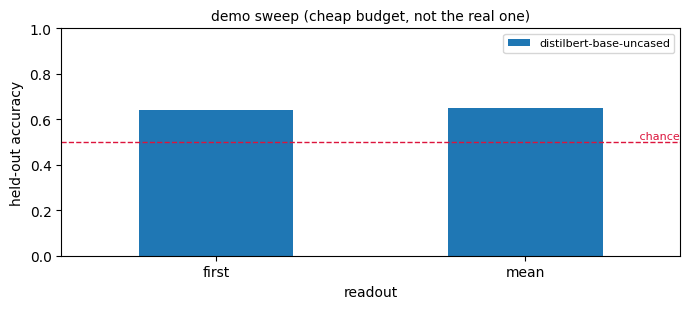

In [9]:
# two configs, one table, one plot -- deliberately cheap (n_train=100, epochs=1)
demo_df, _ = run_grid(
    [dict(readout="first"), dict(readout="mean")],
    model_name="distilbert-base-uncased", n_train=100, epochs=1,
)
print()
print(demo_df[["model_name", "readout", "accuracy", "seconds", "n_trainable"]].to_string(index=False))
_ = plot_accuracy(demo_df, x="readout", title="demo sweep (cheap budget, not the real one)")

---

## 🔬 A1 — Where does the classifier read from?

**The setting.** The application is **binary sentiment classification** on **SST-2**: fine-tune on the
300 labelled sentences of `train_small`, then score accuracy on the 100 held-out sentences of
`eval_small` (chance ≈ 0.5). Two pretrained networks are evaluated on it — **DistilBERT**
(encoder-only) and **GPT-2** (decoder-only) — each with a `LayerNorm` and a fresh `Linear(d, 2)`
head trained by cross-entropy on the labels.

**Why a readout is needed at all.** The body returns one vector **per input token**,
`(batch, seq, d)`. But this application only has to emit **one binary decision per sentence**, so the
sequence must be collapsed into a **single vector** — one readout — before the head can score it.
*Which* vector is normally decided for you and never questioned. Here it is a knob.

**The experiment.** Fine-tune **both networks at all three readouts** (`first`, `last`, `mean`) — 6
runs, everything else at defaults (whole body trainable, 3 epochs, 300 sentences) — and collect the
results into `readout_sweep`. Then **analyse the six accuracies and write your observations and,
above all, *why* you got them.**

The reason this is worth measuring: `readout="first"` points at **the same position** in both bodies,
but Lesson 2's causal mask says it is not the same *information*. In BERT, token 0 is `[CLS]` and it
has attended to the whole sentence; in GPT-2, token 0 has attended to **nothing but itself**, no
matter how long the sentence is.

  [1/6] distilbert-base-uncased/first/all             acc=0.840  trainable= 66,365,954  (7s)
  [2/6] distilbert-base-uncased/last/all              acc=0.850  trainable= 66,365,954  (7s)
  [3/6] distilbert-base-uncased/mean/all              acc=0.840  trainable= 66,365,954  (7s)
  [4/6] gpt2/first/all                                acc=0.480  trainable=124,442,882  (18s)
  [5/6] gpt2/last/all                                 acc=0.530  trainable=124,442,882  (14s)
  [6/6] gpt2/mean/all                                 acc=0.520  trainable=124,442,882  (14s)

readout                  first  last  mean
model_name                                
distilbert-base-uncased   0.84  0.85  0.84
gpt2                      0.48  0.53  0.52


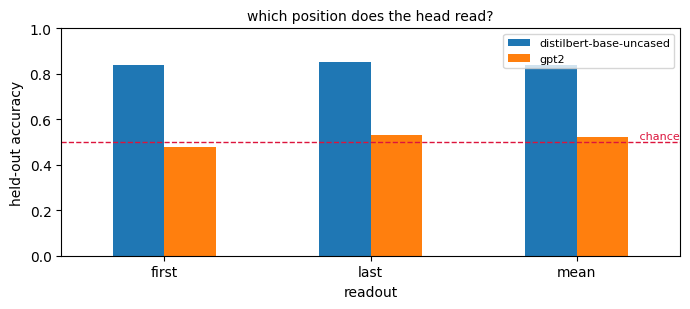

In [10]:
# TODO: fine-tune BOTH bodies at ALL THREE readout positions -- 6 runs, everything else default.
# TODO: collect the six results into a DataFrame called `readout_sweep`.
# TODO: `first` is the SAME position in both bodies -- but is it the same INFORMATION in both?
# TODO: keep GPT-2's best and worst runs alive -- A4 uses them.
# HINT: run_grid([...], keep_models=True) -> (DataFrame, {label: FinetunedRun})
# HINT: plot_accuracy(readout_sweep) draws the chance line for you

readout_sweep, a1_models = run_grid(
    [dict(model_name=m, readout=r)
     for m in ("distilbert-base-uncased", "gpt2")
     for r in READOUTS],
    keep_models=True,
)

print()
print(readout_sweep.pivot_table(index="model_name", columns="readout", values="accuracy").to_string())
_ = plot_accuracy(readout_sweep, x="readout", title="which position does the head read?")

In [11]:
# ✓ check -- A1
try:
    assert len(readout_sweep) >= 6, "expected at least 6 runs (2 bodies x 3 readouts)"
    assert set(readout_sweep.readout) == set(READOUTS), f"all of {READOUTS} must appear"
    assert readout_sweep.model_name.nunique() >= 2, "need both bodies"
    piv = readout_sweep.pivot_table(index="model_name", columns="readout", values="accuracy")
    for body in piv.index:
        spread = piv.loc[body].max() - piv.loc[body].min()
        print(f"  {body:<26} best={piv.loc[body].max():.3f} worst={piv.loc[body].min():.3f} "
              f"spread={spread:.3f}")
    print("✓ A1 experiment complete")
except NameError as e:
    print(f"✗ A1 not attempted yet ({e})")
except Exception as e:
    print(f"✗ A1 check failed: {type(e).__name__}: {e}")

  distilbert-base-uncased    best=0.850 worst=0.840 spread=0.010
  gpt2                       best=0.530 worst=0.480 spread=0.050
✓ A1 experiment complete


### ✍️ A1 conclusion

- **Which readout vector worked best for each model?** Report the six accuracies.
- **Why do you think that was?**

**Resultados (6 runs, todo lo demás en default):**

| model | first | last | mean |
|---|---|---|---|
| distilbert-base-uncased | 0.84 | **0.85** | 0.84 |
| gpt2 | 0.48 | **0.53** | 0.52 |

- **DistilBERT es prácticamente insensible al readout** (spread de solo 0.01 entre las tres opciones): sus tres accuracies caen entre 0.84 y 0.85. Esto tiene sentido porque DistilBERT es encoder-only con atención **bidireccional**: cada token, incluido el token 0, ya atendió a toda la oración durante el forward pass. `[CLS]` fue además pre-entrenado explícitamente como resumen de la secuencia (next-sentence prediction), así que leer de ahí, del último token o promediar todos da información casi idéntica.
- **GPT-2 sí es sensible al readout, y el patrón confirma la máscara causal de la Lección 2**: `first` (0.48, *por debajo* de la línea de azar ≈0.5) es el peor, `last` (0.53) el mejor, `mean` (0.52) queda en medio. En un decoder causal, el token 0 solo pudo atender a sí mismo, no vio el resto de la oración, así que su vector es casi ruido para clasificar sentimiento completo. El último token, es el único que acumuló contexto de toda la secuencia (equivalente a por qué `AutoModelForSequenceClassification` de HuggingFace hardcodea justamente el último token no-pad para GPT-2). El promedio (`mean`) distribuye esa señal buena con vectores tempranos poco informativos, por eso queda entre los dos extremos.
- **Conclusión general**: la posición correcta a leer no es una convención al azar, depende de la dirección de la atención del modelo. En un encoder bidireccional casi cualquier posición sirve; en un decoder causal solo la última posición ha visto toda la oración.

---

## 🔬 A2 — How much of the body has to move?

`trainable` controls how deep the gradients reach: `"head"` trains only the classifier
(the body is frozen), `"last1"`/`"last2"` unfreeze the top block(s), `"all"` trains everything.

Sweep all four on **at least one** body, at that body's best readout from A1. Report `n_trainable`
next to accuracy — the question is not just which wins, but **what each one costs**.

In [12]:
# TODO: sweep trainable = head / last1 / last2 / all on at least ONE body.
# TODO: use that body's BEST readout from A1. Collect the results into `capacity_sweep`.
# TODO: report accuracy AND n_trainable together -- where does the curve flatten?
# TODO: if your first body's answer looks too tidy, run the second one -- they need not agree.
# HINT: run_grid([dict(trainable=t) for t in TRAINABLE], model_name=..., readout=...)

capacity_sweep, _ = run_grid(
    [dict(model_name=m, trainable=t)
     for m in ("distilbert-base-uncased", "gpt2")
     for t in TRAINABLE],
    readout="mean",
)

print()
print(capacity_sweep.pivot_table(index="model_name", columns="trainable",
                                 values="accuracy").to_string())
print()
print(capacity_sweep[["model_name", "trainable", "n_trainable", "accuracy"]].to_string(index=False))

  [1/8] distilbert-base-uncased/mean/head             acc=0.760  trainable=      3,074  (5s)
  [2/8] distilbert-base-uncased/mean/last1            acc=0.850  trainable=  7,090,946  (5s)
  [3/8] distilbert-base-uncased/mean/last2            acc=0.830  trainable= 14,178,818  (6s)
  [4/8] distilbert-base-uncased/mean/all              acc=0.840  trainable= 66,365,954  (7s)
  [5/8] gpt2/mean/head                                acc=0.570  trainable=      3,074  (10s)
  [6/8] gpt2/mean/last1                               acc=0.520  trainable=  7,092,482  (10s)
  [7/8] gpt2/mean/last2                               acc=0.520  trainable= 14,180,354  (10s)
  [8/8] gpt2/mean/all                                 acc=0.520  trainable=124,442,882  (13s)

trainable                 all  head  last1  last2
model_name                                       
distilbert-base-uncased  0.84  0.76   0.85   0.83
gpt2                     0.52  0.57   0.52   0.52

             model_name trainable  n_trainable  ac

In [13]:
# ✓ check -- A2
try:
    assert len(capacity_sweep) >= 4, "expected at least 4 runs (one per trainable setting)"
    assert set(capacity_sweep.trainable) == set(TRAINABLE), f"all of {TRAINABLE} must appear"
    for body, g in capacity_sweep.groupby("model_name"):
        g = g.sort_values("n_trainable")
        gain = g.accuracy.iloc[-1] - g.accuracy.iloc[0]
        cost = g.n_trainable.iloc[-1] / max(g.n_trainable.iloc[0], 1)
        print(f"  {body:<26} head->all: {gain:+.3f} accuracy for {cost:,.0f}x the trainable params")
    print("✓ A2 experiment complete")
except NameError as e:
    print(f"✗ A2 not attempted yet ({e})")
except Exception as e:
    print(f"✗ A2 check failed: {type(e).__name__}: {e}")

  distilbert-base-uncased    head->all: +0.080 accuracy for 21,589x the trainable params
  gpt2                       head->all: -0.050 accuracy for 40,482x the trainable params
✓ A2 experiment complete


### ✍️ A2 conclusion

- **How did the accuracy improve as you trained more layers?** Report accuracy next to `n_trainable`.
- **How many layers do you consider necessary to train — if any?**

**Resultados (`readout="mean"`, sweep de `trainable` en ambos cuerpos):**

| model | head (3,074 params) | last1 (7.09M) | last2 (14.18M) | all (66.4M / 124.4M) |
|---|---|---|---|---|
| distilbert-base-uncased | 0.76 | **0.85** | 0.83 | 0.84 |
| gpt2 | **0.57** | 0.52 | 0.52 | 0.52 |

- **DistilBERT: `head->all` da +0.080 de accuracy pero a costa de 21,589x más parámetros entrenables.** El máximo real no está en `all` (0.84) sino en `last1` (0.85), descongelar solo el último bloque encoder ya captura casi toda la ganancia, y seguir descongelando más capas no ayuda. Con solo 300 oraciones de entrenamiento, mover 66M de parámetros probablemente empieza a sobreajustar un poco.
- **GPT-2 muestra el patrón opuesto: `head->all` da -0.050**, entrenar solo el head (dejando el cuerpo preentrenado intacto) fue la mejor opción (0.57) y fine-tunear todo el modelo fue la peor (0.52). Esto es consistente con A1: como el `readout="mean"` ya diluye la señal útil de GPT-2, dejar que 124M de parámetros se muevan con gradientes ruidosos (300 ejemplos) degrada las representaciones preentrenadas en vez de mejorarlas.
- **¿Cuántas capas vale la pena entrenar?** Para DistilBERT, con solo la última capa (`last1`) ya se obtiene el máximo, entrenar el modelo completo no se justifica en este régimen de datos. Para GPT-2, la respuesta es ninguna: en este experimento ni siquiera vale la pena descongelar una capa, el mejor resultado fue no tocar el cuerpo en absoluto. El costo computacional y el riesgo de sobreajuste con pocos datos suben mucho más rápido de lo que sube la accuracy.

---

## 🔬 A3 — Where does the accuracy actually come from?

Two sub-experiments, one question: is the model's skill coming from **pretraining** or from **your
300 sentences**?

**(a)** Same architecture, `pretrained=True` vs `pretrained=False` — identical shape, random weights.
**(b)** `n_train` ∈ {50, 150, 300} at the defaults.

Collect both into `origin_sweep`.

In [14]:
# TODO: (a) pretrained=True vs pretrained=False -- same architecture, random weights.
# TODO: (b) n_train in {50, 150, 300}.
# TODO: collect both into `origin_sweep`, with a column saying which sub-experiment each row is.
# TODO: which axis buys more accuracy -- better weights, or more data?
# HINT: run_grid([dict(pretrained=p) for p in (True, False)], model_name=...)
# HINT: pd.concat([...]) stacks the two sub-experiments into one frame

a3a, _ = run_grid([dict(model_name=m, pretrained=p)
                   for m in ("distilbert-base-uncased", "gpt2")
                   for p in (True, False)])
a3a["part"] = "a: weights"

a3b, _ = run_grid([dict(n_train=n) for n in (50, 150, 300)])
a3b["part"] = "b: data"

origin_sweep = pd.concat([a3a, a3b], ignore_index=True)

print()
print("(a) pretrained vs random")
print(a3a[["model_name", "pretrained", "accuracy"]].to_string(index=False))
print()
print("(b) how much data")
print(a3b[["model_name", "n_train", "accuracy"]].to_string(index=False))

  [1/4] distilbert-base-uncased/mean/all              acc=0.840  trainable= 66,365,954  (7s)
  [2/4] distilbert-base-uncased/mean/all              acc=0.550  trainable= 66,365,954  (8s)
  [3/4] gpt2/mean/all                                 acc=0.520  trainable=124,442,882  (14s)
  [4/4] gpt2/mean/all                                 acc=0.460  trainable=124,442,882  (15s)
  [1/3] distilbert-base-uncased/mean/all              acc=0.780  trainable= 66,365,954  (3s)
  [2/3] distilbert-base-uncased/mean/all              acc=0.780  trainable= 66,365,954  (4s)
  [3/3] distilbert-base-uncased/mean/all              acc=0.840  trainable= 66,365,954  (7s)

(a) pretrained vs random
             model_name  pretrained  accuracy
distilbert-base-uncased        True      0.84
distilbert-base-uncased       False      0.55
                   gpt2        True      0.52
                   gpt2       False      0.46

(b) how much data
             model_name  n_train  accuracy
distilbert-base-uncased      

In [15]:
# ✓ check -- A3
try:
    assert len(origin_sweep) >= 5, "expected sub-experiments (a) and (b) stacked together"
    assert origin_sweep.pretrained.nunique() >= 2, "(a) needs both pretrained=True and False"
    assert origin_sweep.n_train.nunique() >= 2, "(b) needs at least two n_train values"
    pre = origin_sweep[origin_sweep.pretrained]
    rnd = origin_sweep[~origin_sweep.pretrained]
    if len(rnd):
        print(f"  pretrained mean acc = {pre.accuracy.mean():.3f}   "
              f"random-init mean acc = {rnd.accuracy.mean():.3f}   "
              f"gap = {pre.accuracy.mean() - rnd.accuracy.mean():+.3f}")
    d = origin_sweep[origin_sweep.part == "b: data"].sort_values("n_train")
    if len(d) >= 2:
        print(f"  n_train {d.n_train.iloc[0]} -> {d.n_train.iloc[-1]}: "
              f"{d.accuracy.iloc[0]:.3f} -> {d.accuracy.iloc[-1]:.3f} "
              f"({d.accuracy.iloc[-1] - d.accuracy.iloc[0]:+.3f})")
    print("✓ A3 experiment complete")
except NameError as e:
    print(f"✗ A3 not attempted yet ({e})")
except Exception as e:
    print(f"✗ A3 check failed: {type(e).__name__}: {e}")

  pretrained mean acc = 0.752   random-init mean acc = 0.505   gap = +0.247
  n_train 50 -> 300: 0.780 -> 0.840 (+0.060)
✓ A3 experiment complete


### ✍️ A3 conclusion

- **How did the result change between the pretrained transformer and the non-pretrained one?** Report
  both, and what more data (`n_train`) bought on top.
- **Why do you think you got those results?**

**(a) Pretrained vs. arquitectura idéntica con pesos aleatorios:**

| model | pretrained=True | pretrained=False | gap |
|---|---|---|---|
| distilbert-base-uncased | 0.84 | 0.55 | +0.29 |
| gpt2 | 0.52 | 0.46 | +0.06 |

Promedio: acc con preentrenamiento = 0.752, acc con pesos aleatorios = 0.505 → **gap de +0.247**.

**(b) Cantidad de datos (`n_train`, DistilBERT, defaults):**

| n_train | accuracy |
|---|---|
| 50 | 0.78 |
| 150 | 0.78 |
| 300 | 0.84 |

- **El preentrenamiento es, con mucho, el eje que más pesa.** Para DistilBERT, pasar de pesos aleatorios a pesos preentrenados aporta +0.29 de accuracy, más de lo que aporta cuadruplicar los datos de entrenamiento en este experimento. DistilBERT con pesos aleatorios (0.55) apenas supera el azar (~0.5), mientras que con solo 50 oraciones y pesos preentrenados ya alcanza 0.78. Es decir: el conocimiento del lenguaje que trae el preentrenamiento vale mucho más que cualquier cantidad de datos de fine-tuning que podamos darle aquí.
- **GPT-2 confirma la misma idea pero al revés: como su gap pretrained-vs-random es solo +0.06 (0.52 vs 0.46), el preentrenamiento casi no le está sirviendo con `readout="mean"`.** Esto encaja con A1/A2: si el readout diluye la información útil, no importa cuán bueno sea el modelo preentrenado por debajo, casi no hay ventaja real que aprovechar.
- **Más datos sí ayuda, pero con rendimientos decrecientes**: de 50→150 oraciones no hubo ningún cambio (0.78→0.78), y solo al llegar a 300 subió a 0.84. Con una muestra tan pequeña de SST-2, el modelo preentrenado parece necesitar cierto umbral de ejemplos antes de que el fine-tuning despierte al head nuevo, más que una mejora gradual y continua.

---

## 🔬 A4 — Now actually use them

Accuracy on 100 held-out sentences is a summary statistic, and A1–A3 never looked at a single
prediction. Take the models you trained and **run them on text you wrote**, then read what they
output.

Run your **best** and your **worst** configuration on **≥ 6 sentences of your own**, including
**≥ 2 that are hard on purpose** — negation ("not bad at all"), mixed sentiment, or praise-shaped
sarcasm.

In [16]:
# TODO: run your BEST and your WORST configuration on >= 6 sentences you write yourself.
# TODO: include >= 2 that are hard on purpose: negation, mixed sentiment, or sarcasm.
# TODO: store the two prediction tables as `best_preds` and `worst_preds`.
# TODO: look at the WORST model's p_positive COLUMN, not its labels. What is it doing?
# TODO: what does that column tell you that its accuracy number alone did not?
# HINT: run.predict(sentences) -> DataFrame[sentence, pred, p_positive]
# HINT: a1_models holds the runs A1 kept -- print list(a1_models) to see the labels

MY_SENTENCES = [
    "A stirring, funny and finally transporting film.",
    "This movie is not bad at all.",                              # negation
    "The first hour is gorgeous but the second half falls apart.",  # mixed
    "Great. Another two hours I will never get back.",            # sarcasm
    "The acting is superb though the script is thin.",            # mixed
    "Utterly forgettable.",
]

best_label = "gpt2/last/all"       # GPT-2's working readout
worst_label = "gpt2/first/all"     # the one the causal mask breaks

best_preds = a1_models[best_label].predict(MY_SENTENCES)
worst_preds = a1_models[worst_label].predict(MY_SENTENCES)

print(f"-- BEST: {best_label} (held-out acc {a1_models[best_label].accuracy:.3f}) --")
print(best_preds.to_string(index=False))
print(f"\n-- WORST: {worst_label} (held-out acc {a1_models[worst_label].accuracy:.3f}) --")
print(worst_preds.to_string(index=False))

-- BEST: gpt2/last/all (held-out acc 0.530) --
                                                   sentence     pred  p_positive
           A stirring, funny and finally transporting film. positive       0.502
                              This movie is not bad at all. negative       0.495
The first hour is gorgeous but the second half falls apart. negative       0.493
            Great. Another two hours I will never get back. negative       0.468
            The acting is superb though the script is thin. negative       0.475
                                       Utterly forgettable. negative       0.484

-- WORST: gpt2/first/all (held-out acc 0.480) --
                                                   sentence     pred  p_positive
           A stirring, funny and finally transporting film. negative       0.483
                              This movie is not bad at all. negative       0.490
The first hour is gorgeous but the second half falls apart. negative       0.484
            

In [17]:
# ✓ check -- A4
try:
    assert len(best_preds) >= 6, "use at least 6 sentences"
    assert len(worst_preds) >= 6, "run the same sentences through both models"
    for name, df in (("best", best_preds), ("worst", worst_preds)):
        sd = float(df.p_positive.std())
        rng = float(df.p_positive.max() - df.p_positive.min())
        print(f"  {name:<6} p_positive: std={sd:.4f}  range={rng:.3f}  "
              f"({'essentially CONSTANT' if sd < 0.05 else 'varies with the sentence'})")
    print("✓ A4 experiment complete")
except NameError as e:
    print(f"✗ A4 not attempted yet ({e})")
except Exception as e:
    print(f"✗ A4 check failed: {type(e).__name__}: {e}")

  best   p_positive: std=0.0129  range=0.034  (essentially CONSTANT)
  worst  p_positive: std=0.0036  range=0.011  (essentially CONSTANT)
✓ A4 experiment complete


### ✍️ A4 conclusion

- **How did each model perform, judging by the `p_positive` column?** Look at its spread across your
  sentences, not just the predicted labels.
- **A model can beat chance and still emit nearly the same output for every input.** Explain how that
  can be true, and why it matters.
- **Based on your results, which model do you consider the best, and why?**

**Predicciones sobre 6 oraciones propias (2 difíciles: negación y sarcasmo/mixta):**

- **BEST — `gpt2/last/all`** (acc en held-out = 0.530): predijo positive solo en la primera oración (p=0.502) y negative en las otras cinco, con probabilidades que van de 0.468 a 0.502. `std(p_positive)=0.0129`, rango=0.034 → prácticamente constante.
- **WORST — `gpt2/first/all`** (acc en held-out = 0.480): predijo negative en las seis, con probabilidades entre 0.479 y 0.490. `std=0.0036`, rango=0.011 → aún más constante que el "mejor" modelo.

- **¿Qué dice la columna `p_positive` que la accuracy no dice?** Que ninguno de los dos modelos realmente está leyendo la oración. Un clasificador que funcionara de verdad debería dar probabilidades altas y bajas dependiendo del contenido, aquí ambos oscilan apenas ±0.02–0.03 alrededor de 0.48–0.50 sin importar si la oración dice "stirring and funny" o "another two hours I will never get back". El modelo "best" apenas cruza 0.5 en una sola oración, el resto del tiempo, tanto el mejor como el peor modelo se comportan casi como un clasificador que siempre dice "negative" (o casi tira una moneda al aire).
- **¿Cómo puede un modelo superar el azar (0.53 > ~0.5) y aun así emitir una salida casi constante?** Porque el conjunto de evaluación (`eval_small`) tiene un desbalance leve de clases (48 negativas / 52 positivas), así que un modelo que casi siempre predice la clase mayoritaria, con solo un poquito de variación real por oración, puede quedar un par de puntos por encima de 0.5 sin haber aprendido una frontera de decisión significativa. La accuracy en 100 oraciones no distingue entre "aprendió a distinguir sentimiento" y "aprendió a inclinarse levemente hacia una clase".
- **¿Cuál modelo es mejor, y por qué?** Ninguno de los dos GPT-2 es un buen clasificador en términos absolutos, pero `gpt2/last/all` es el "menos malo": tiene mejor accuracy en el held-out (0.53 vs 0.48) y al menos logra distinguir una oración como positiva, mientras que `gpt2/first/all` colapsa completamente a predecir siempre "negative". Esto es consistente con A1: el readout `last` es el único que en un decoder causal ha visto toda la oración, así que aunque el resultado siga siendo débil, es la única configuración de las dos con alguna señal real.

---

### What this lab produced that an accuracy table could not

A model you can **call**. The sweeps in A1–A3 said which configuration won; `run.predict(...)` shows
you *how* it wins, and — more usefully — how it fails. A model can post a respectable accuracy on a
100-sentence eval slice and still emit a nearly constant probability, or still get "not bad at all"
backwards. Only the predictions show that.

If your kernel is running short on memory, `free(...)` releases any runs you kept, and restarting the
kernel clears everything Part 0 loaded as well.